# Análisis Predictivo - Evaluación 3

El archivo que se le suministra es un conjunto de datos de pacientes con cáncer de mama se obtuvo de la actualización de noviembre de 2017 del Programa SEER del NCI, que proporciona información sobre estadísticas de cáncer basadas en la población. El conjunto de datos incluyó a pacientes de sexo femenino con cáncer de mama de carcinoma lobular y ductal infiltrante (códigos histológicos 8522/3 de recodificación NOS de citas primarias del SEER) diagnosticado entre 2006 y 2010.

Las variables que contiene este dataset son:

1. Age: Se refiere a la edad del paciente en el momento del diagnóstico.
2. Race: raza o etnia del paciente.
3. Marital Status: El estado civil del paciente (casado, soltero, divorciado, etc.).
4. T Stage: La clasificación del tamaño o extensión del tumor primario (normalmente se utiliza en el sistema TNM).
5. N Stage: Se refiere a la extensión del cáncer a los ganglios linfáticos cercanos.
6. 6th State: Puede referirse al estadio del cáncer según una clasificación específica (como la clasificación AJCC).
7. differentiate: Se refiere al grado de diferenciación celular del tumor (lo diferentes que son las células tumorales de las células normales), un factor utilizado para determinar la agresividad del cáncer.
8. Grade: Se refiere al grado de progresión del tumor o cáncer y a cuánto se ha extendido.
9. A Stage: Puede referirse a un estadio específico en la clasificación por estadios del cáncer.
10. Tumor Size: El tamaño medido del tumor primario.
11. Estrogen Status: Estado de los receptores de estrógenos en las células cancerosas (positivo o negativo), que afecta al tratamiento.
12. Progesterone Status: Estado de los receptores de progesterona en las células cancerosas (positivo o negativo).
13. Regional Node Examined: El número de ganglios linfáticos examinados para detectar la propagación del cáncer.
14. Reginol Node Positive: El número de ganglios linfáticos que dieron positivo para el cáncer.
15. Survival Monyhs: El número de meses que el paciente estuvo vivo después del diagnóstico.
16. Status: El estado final del paciente (como supervivencia o muerte).

Se creo un modelo de regresión logística para predecir la variable **Status**, con los siguientes resultados:

```
                precision    recall  f1-score   support

       Alive       0.95      0.81      0.88       678
        Dead       0.42      0.76      0.54       121

    accuracy                           0.80       799
   macro avg       0.69      0.79      0.71       799
weighted avg       0.87      0.80      0.83       799

```

# Parte 1

Haga un modelo de bosque aleatorio para predecir la variable **Status**.

Particione los datos en una proporción 80/20, haciendo `random_state=1`, y `stratify=y`.

El modelo debe ser sintonizado.

Reporte:
- El score de validación y los valores de los hiperparámetros sintonizados.
- El score de entrenamiento.
- El score de prueba.
- La matriz de confusión
- El reporte de clasificación.
- La importancia relativa de cada característica del modelo en un dataframe.

El objetivo es que el modelo supere el f1-score del modelo de regresión logísitca. Así:
- Si el f1-score obtenido es menor a 0.54, la máxima nota que obtendrá es 3.0.
- Si el f1-score obtenido es menor a 0.57, la máxima nota que obtendrá es 4.0.
- Si el f1-score obtenido es menor a 0.59, la máxima nota que obtendrá es 4.5.

In [32]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer

file_path = 'Breast_Cancer_dataset.csv' 

df = pd.read_csv(file_path,
    na_values=[' ',' -  ', 'nan', 'NaN', 'NA', 'n/a', 'N/A', 'na', '--'],
    sep=';'
) 

# Daba errores de nulos en la matriz de confusion y en el entrenamiento pese a ser random Tree
df = df.dropna(subset=['Status'])

In [33]:
X = df.drop(columns=['Status'])
y = df['Status']

le = LabelEncoder()
y = le.fit_transform(y) 

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

In [35]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(random_state=1))
])

param_grid_rf = {
    'classifier__n_estimators': [50, 100, 150],       
    'classifier__max_depth': [4, 6, 8],                
    'classifier__min_samples_split': [10, 20, 30],     
    'classifier__min_samples_leaf': [5, 10, 15],       
    'classifier__class_weight': ['balanced', None]     
}


In [36]:
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)


/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'classifier__class_weight': ['balanced', None], 'classifier__max_depth': [4, 6, ...], 'classifier__min_samples_leaf': [5, 10, ...], 'classifier__min_samples_split': [10, 20, ...], ...}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...)]"


In [37]:
print("RESULTADOS SINTONIZACIÓN")
print(f"Mejor validación : {grid_rf.best_score_:.4f}")
print("Mejores hiperparámetros:\n")
for k, v in grid_rf.best_params_.items():
    print(f"{k}: {v}")
    
best_rf = grid_rf.best_estimator_
print(f"Score Entrenamiento: {best_rf.score(X_train, y_train):.4f}")
print(f"Score Prueba: {best_rf.score(X_test, y_test):.4f}\n")



RESULTADOS SINTONIZACIÓN
Mejor validación : 0.8915
Mejores hiperparámetros:

classifier__class_weight: None
classifier__max_depth: 8
classifier__min_samples_leaf: 5
classifier__min_samples_split: 20
classifier__n_estimators: 150
Score Entrenamiento: 0.9173
Score Prueba: 0.9051



/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [38]:
y_pred_rf = best_rf.predict(X_test)
print("REPORTE DE CLASIFICACIÓN")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

       Alive       0.91      0.99      0.95       680
        Dead       0.85      0.45      0.59       121

    accuracy                           0.91       801
   macro avg       0.88      0.72      0.77       801
weighted avg       0.90      0.91      0.89       801



/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


MATRIZ DE CONFUSIÓN


/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


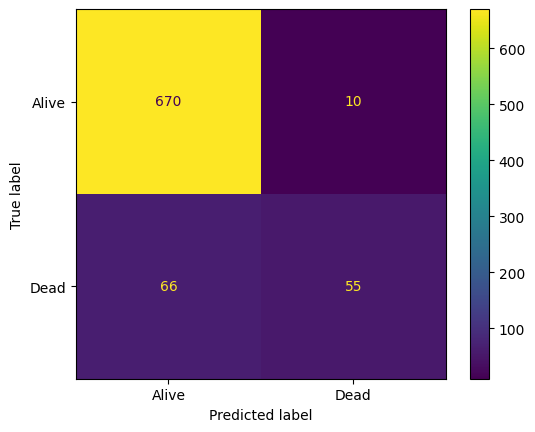

In [39]:
print("MATRIZ DE CONFUSIÓN")
ConfusionMatrixDisplay.from_estimator(
    grid_rf.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
)

In [40]:
importances_rf = best_rf.named_steps['classifier'].feature_importances_
features_rf = best_rf.named_steps['preprocessor'].get_feature_names_out()

df_importances_rf = pd.DataFrame({
    'Feature': features_rf,
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\n IMPORTANCIA DE CARACTERÍSTICAS")
print(df_importances_rf)


 IMPORTANCIA DE CARACTERÍSTICAS
                                     Feature  Importance
0                 remainder__Survival Months    0.548208
1           remainder__Reginol Node Positive    0.070148
2                             remainder__Age    0.055291
3                      remainder__Tumor Size    0.047305
4                            cat__N Stage_N3    0.036436
5              cat__Estrogen Status_Positive    0.035033
6          remainder__Regional Node Examined    0.034095
7                        cat__6th Stage_IIIC    0.032563
8          cat__Progesterone Status_Positive    0.032541
9   cat__differentiate_Poorly differentiated    0.016979
10                              cat__Grade_3    0.015826
11                           cat__N Stage_N2    0.009436
12               cat__Marital Status_Married    0.009056
13                              cat__Grade_2    0.007987
14                          cat__T Stage _T2    0.006110
15               cat__Marital Status_Single     0.00504

# Parte 2
 
Haga un modelo de boosting para predecir la variable **Status**.

Particione los datos en una proporción 80/20, haciendo `random_state=1`, y `stratify=y`.

El modelo debe ser sintonizado.

Reporte:
- El score de validación y los valores de los hiperparámetros sintonizados.
- El score de entrenamiento.
- El score de prueba.
- La matriz de confusión
- El reporte de clasificación.
- La importancia relativa de cada característica del modelo en un dataframe.

El objetivo es que el modelo supere el recall score del modelo de regresión logísitca. Así:
- Si el recall obtenido es menor a 0.50, la máxima nota que obtendrá es 3.0.
- Si el recall obtenido es menor a 0.60, la máxima nota que obtendrá es 4.0.
- Si el recall obtenido es menor a 0.80, la máxima nota que obtendrá es 4.5.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')) 
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor_gb = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

In [42]:
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_gb),
    ('classifier', GradientBoostingClassifier(random_state=1))
])

param_grid_gb = {
    'classifier__n_estimators': [50, 100, 150],       
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 4, 5],
    'classifier__min_samples_leaf': [5, 10]
}

In [43]:
grid_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)



,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__min_samples_leaf': [5, 10], 'classifier__n_estimators': [50, 100, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [44]:
print("RESULTADOS SINTONIZACIÓN")
print(f"Mejor validación: {grid_gb.best_score_:.4f}")
print("Mejores hiperparámetros:\n")
for k, v in grid_gb.best_params_.items():
    print(f"{k}: {v}")

best_gb = grid_gb.best_estimator_
print(f"Score Entrenamiento: {best_gb.score(X_train, y_train):.4f}")
print(f"Score Prueba: {best_gb.score(X_test, y_test):.4f}\n")


RESULTADOS SINTONIZACIÓN
Mejor validación: 0.5125
Mejores hiperparámetros:

classifier__learning_rate: 0.1
classifier__max_depth: 3
classifier__min_samples_leaf: 5
classifier__n_estimators: 150
Score Entrenamiento: 0.9298
Score Prueba: 0.8964



In [45]:
y_pred_gb = best_gb.predict(X_test)
print("REPORTE CLASIFICACIÓN")
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))

REPORTE CLASIFICACIÓN
              precision    recall  f1-score   support

       Alive       0.92      0.97      0.94       680
        Dead       0.73      0.50      0.60       121

    accuracy                           0.90       801
   macro avg       0.82      0.74      0.77       801
weighted avg       0.89      0.90      0.89       801



MATRIZ DE CONFUSIÓN


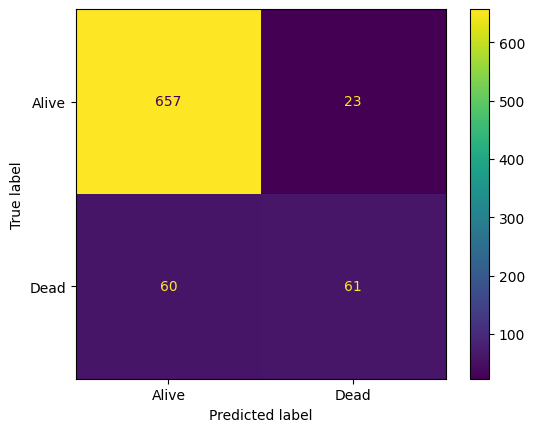

In [46]:
print("MATRIZ DE CONFUSIÓN")
ConfusionMatrixDisplay.from_estimator(
    grid_gb.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
)

In [47]:
importances_gb = best_gb.named_steps['classifier'].feature_importances_
features_gb = best_gb.named_steps['preprocessor'].get_feature_names_out()

df_importances_gb = pd.DataFrame({
    'Feature': features_gb,
    'Importance': importances_gb
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\nIMPORTANCIA DE CARACTERÍSTICAS")
print(df_importances_gb)


IMPORTANCIA DE CARACTERÍSTICAS
                                     Feature  Importance
0                       num__Survival Months    0.711913
1                 num__Reginol Node Positive    0.076170
2                                   num__Age    0.068851
3                            num__Tumor Size    0.033993
4                num__Regional Node Examined    0.025295
5          cat__Progesterone Status_Positive    0.020538
6              cat__Estrogen Status_Positive    0.010297
7   cat__differentiate_Poorly differentiated    0.009069
8                cat__Marital Status_Married    0.005851
9                               cat__Grade_2    0.005456
10                              cat__Grade_3    0.005017
11                           cat__Race_White    0.003584
12             cat__Marital Status_Separated    0.003316
13                           cat__Race_Other    0.003243
14                        cat__6th Stage_IIB    0.003211
15                           cat__N Stage_N2    0.003166

# Condiciones de entrega de la evaluación:

- Debe entregar un archivo en formato .ipynb. No se admiten URLs.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura (código redundante, funciones innecesarias, versiones preliminares de modelos). Solo entregue el código que de respuesta a lo que se le pide que haga.
